### **Predicting Recommendation Probability Using Regression Model on User Interaction on E-commerce Products**



---



###I. Defining the Business Problem

The objective of this project is to develop a content-based recommendation model for an e-commerce platform that accurately predicts the probability of a product being recommended to another customer. This will enhance personalization and optimize product discovery by providing highly relevant product suggestions that are likely to resonate with individual user preferences, ultimately increasing user engagement, conversion rates, and overall customer satisfaction.

The model aims to achieve an **R-squared score of greater or equal to 0.85**, explaining at least 85% of the total variation in actual product recommendation probabilities. This target was intentionally selected to enable the model to identify the most relevant products for recommendation while reserving the remaining 15% for recommendation diversity.

An overview of the project is, first, we must preprocess the data by describing and visualizing it using tables and graphs, select relevant features as well as scaling those for calculation purposes. Then, we will determine the best regression model to be used as the data contains a continuous recommendation probability and consequently evaluate those using regression metrics (MAE, MSE, RMSE and R2). After that, we shall proceed to tune the model and talk about biases.



---



###II. Data Collection & Content Preview

First and foremost, we import and inspect the selected ecommerce data from Kagglehub. Note that the code block below has an (commented out) option to upload a CSV file if needed.

In [1]:
import kagglehub
import pandas as pd
import os
from google.colab import files # Needed for local file uploads

# --- Data Loading Options ---
# Please choose ONE of the options below by uncommenting the desired section
# and commenting out the other. Only one option should be active at a time.

df = None # Initialize df to None, it will be populated by the chosen option

# Option 1: Load data from Kagglehub (Currently Active)
# This option downloads a dataset directly from Kagglehub.
# You can change the 'kaggle_dataset_identifier' to point to a different dataset.

try:
    kaggle_dataset_identifier = "kartikeybartwal/ecomerce-product-recommendation-dataset"
    path = kagglehub.dataset_download(kaggle_dataset_identifier)

    print(f"Path to dataset files from Kagglehub: {path}")

    files_in_path = os.listdir(path)
    print(f"Files in Kagglehub dataset directory: {files_in_path}")

    # Assuming there's a CSV file, find and load it
    csv_files_kaggle = [f for f in files_in_path if f.endswith('.csv')]

    if csv_files_kaggle:
        data_file_path_kaggle = os.path.join(path, csv_files_kaggle[0])
        df = pd.read_csv(data_file_path_kaggle)
        print("\nDataFrame loaded successfully from Kagglehub.")
    else:
        print("No CSV files found in the Kagglehub dataset directory.")
except Exception as e:
    print(f"Error loading data from Kagglehub: {e}")

#==============================================================================
#==============================================================================
# Option 2: Upload a local CSV file (Currently Commented Out)
# Uncomment this section to use. This allows you to upload a CSV file from your local machine.
# If activating this option, ensure Option 1 is fully commented out.

# uploaded_file_name = None
# try:
#     print("\nTo upload a file, run this cell, then click 'Choose Files' in the output.")
#     uploaded = files.upload()
#     if uploaded:
#         uploaded_file_name = list(uploaded.keys())[0]
#         print(f"File '{uploaded_file_name}' uploaded successfully.")
#         df = pd.read_csv(uploaded_file_name)
#         print(f"\nDataFrame loaded successfully from uploaded file '{uploaded_file_name}'.")
#     else:
#         print("No file was uploaded.")
# except Exception as e:
#     print(f"Error during file upload or reading: {e}")
#==============================================================================
#==============================================================================

# --- Common Data Inspection ---
# This section runs regardless of which loading option was chosen.
if df is not None:
    print("\n--- Initial DataFrame Overview ---")
    print("\nDataFrame head:")
    display(df.head())

    print("\nDataFrame Info:")
    df.info()

    print("\nDataFrame Description (Numerical Columns):")
    display(df.describe())
else:
    print("\nWarning: No DataFrame could be loaded. Please ensure one of the data loading options above successfully loads data.")


Using Colab cache for faster access to the 'ecomerce-product-recommendation-dataset' dataset.
Path to dataset files from Kagglehub: /kaggle/input/ecomerce-product-recommendation-dataset
Files in Kagglehub dataset directory: ['content_based_recommendation_dataset.csv']

DataFrame loaded successfully from Kagglehub.

--- Initial DataFrame Overview ---

DataFrame head:


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Gender,Median purchasing price (in rupees),Rating of the product,Brand of the product,Customer review sentiment score (overall),Price of the product,Holiday,Season,Geographical locations,Probability for the product to be recommended to the person
0,12,4,4.2,male,500,4.5,PUMA,0.8,200,No,winter,plains,0.9
1,8,2,3.8,female,3000,3.2,Lee,-0.4,300,Yes,monsoon,mountains,0.2
2,25,10,4.5,female,600,4.8,Head Hunters,0.6,1000,No,spring,plains,0.7
3,6,1,2.1,female,100,2.5,Johnson & Johnson,0.1,300,No,summer,coastal,0.1
4,18,5,4.7,male,2000,4.3,Wakefit,0.9,700,Yes,winter,plains,0.8



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 13 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Number of clicks on similar products                         1474 non-null   int64  
 1   Number of similar products purchased so far                  1474 non-null   int64  
 2   Average rating given to similar products                     1474 non-null   float64
 3   Gender                                                       1474 non-null   object 
 4   Median purchasing price (in rupees)                          1474 non-null   int64  
 5   Rating of the product                                        1474 non-null   float64
 6   Brand of the product                                         1474 non-null   object 
 7   Customer review sentiment score (overall)                    

,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Probability for the product to be recommended to the person
count,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000
mean,20.846676,9.225237,3.970963,2720.284939,4.059430,0.473474,1142.910448,0.674562
std,11.315669,5.356612,0.832315,3045.898434,0.829928,0.503922,1961.069130,0.317863
min,0.000000,0.000000,0.000000,100.000000,0.000000,-1.000000,90.000000,0.000000
25%,11.000000,5.000000,3.400000,500.000000,3.500000,0.100000,400.000000,0.450000
50%,19.000000,9.000000,4.200000,1000.000000,4.300000,0.700000,600.000000,0.800000
75%,28.750000,13.000000,4.700000,5000.000000,4.800000,0.900000,900.000000,0.900000
max,55.000000,24.000000,5.000000,19000.000000,5.000000,1.000000,10000.000000,1.000000


Secondly, we create a data dictionary and display it using tables for better viewing.

In [2]:
import pandas as pd

# Ensure df is loaded from the previous cell
if 'df' not in locals() or df is None:
    print("DataFrame 'df' not found. Please run the data loading cell first.")
else:
    data_dict = []
    for col in df.columns:
        col_type = str(df[col].dtype)
        description = ""
        stats_info = ""

        if col_type in ['int64', 'float64']:
            # Numerical column
            min_val = df[col].min()
            max_val = df[col].max()
            mean_val = df[col].mean()

            unit = ""

            if col == 'Number of clicks on similar products':
                description = 'User clicks on similar products.'
                unit = 'clicks'
            elif col == 'Number of similar products purchased so far':
                description = 'Similar products purchased by user.'
                unit = 'units'
            elif col == 'Average rating given to similar products':
                description = 'Avg. rating (1-5) on similar products.'
                unit = 'rating scale (1-5)'
            elif col == 'Median purchasing price (in rupees)':
                description = 'Median purchase price.'
                unit = 'INR'
            elif col == 'Rating of the product':
                description = 'Product rating (1-5).'
                unit = 'rating scale (1-5)'
            elif col == 'Customer review sentiment score (overall)':
                description = 'Overall customer review sentiment (-1 to 1).'
                unit = 'sentiment score'
            elif col == 'Price of the product':
                description = 'Product price.'
                unit = 'INR'
            elif col == 'Probability for the product to be recommended to the person':
                description = 'Target: Product recommendation probability.'
                unit = 'probability (0-1)'
            else:
                description = 'Numerical feature.'

            stats_info = f"Range: [{min_val:.2f}-{max_val:.2f}] (Mean: {mean_val:.2f})"
            if unit: # Append unit only if it's not empty
                stats_info += f" [{unit}]"

        elif col_type == 'object':
            # Categorical column
            unique_values = df[col].unique()

            if col == 'Gender':
                description = 'Customer gender.'
            elif col == 'Brand of the product':
                description = 'Product brand name.'
            elif col == 'Holiday':
                description = 'Holiday context.'
            elif col == 'Season':
                description = 'Season of year.'
            elif col == 'Geographical locations':
                description = 'Geographical location.'
            else:
                description = 'Categorical feature.'

            if len(unique_values) <= 5: # If few unique values, list them
                stats_info = f"Categories: {', '.join(map(str, unique_values))}"
            else: # Otherwise, just show the count
                stats_info = f"Categories: {len(unique_values)} unique values"

        data_dict.append({"Variable": col, "Type": col_type, "Description": description, "Details": stats_info})

    data_dictionary_df = pd.DataFrame(data_dict)
    print("### Data Dictionary")
    # Display the DataFrame directly for better alignment and visual presentation
    display(data_dictionary_df)


### Data Dictionary


,Variable,Type,Description,Details
0,Number of clicks on similar products,int64,User clicks on similar products.,Range: [0.00-55.00] (Mean: 20.85) [clicks]
1,Number of similar products purchased so far,int64,Similar products purchased by user.,Range: [0.00-24.00] (Mean: 9.23) [units]
2,Average rating given to similar products,float64,Avg. rating (1-5) on similar products.,Range: [0.00-5.00] (Mean: 3.97) [rating scale ...
3,Gender,object,Customer gender.,"Categories: male, female"
4,Median purchasing price (in rupees),int64,Median purchase price.,Range: [100.00-19000.00] (Mean: 2720.28) [INR]
5,Rating of the product,float64,Product rating (1-5).,Range: [0.00-5.00] (Mean: 4.06) [rating scale ...
6,Brand of the product,object,Product brand name.,Categories: 48 unique values
7,Customer review sentiment score (overall),float64,Overall customer review sentiment (-1 to 1).,Range: [-1.00-1.00] (Mean: 0.47) [sentiment sc...
8,Price of the product,int64,Product price.,Range: [90.00-10000.00] (Mean: 1142.91) [INR]
9,Holiday,object,Holiday context.,"Categories: No, Yes"


###III. Data Preprocessing, Exploratory Data Analysis, & Feature Engineering

Now that we had initially seen the content of our data, we then clean it via handling null entries or duplicates.

In [3]:
print("\n--- Checking for Missing Values ---")
missing_values = df.isnull().sum()
print("Number of missing values per column:\n", missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the DataFrame.")
else:
    print(f"Total missing values in the DataFrame: {missing_values.sum()}")

print("\n--- Checking for Duplicate Entries ---")
duplicate_rows = df.duplicated().sum()
if duplicate_rows == 0:
    print("No duplicate rows found in the DataFrame.")
else:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    print("Displaying the first 10 duplicate rows (duplicates across all columns):")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))


--- Checking for Missing Values ---
Number of missing values per column:
 Series([], dtype: int64)
No missing values found in the DataFrame.

--- Checking for Duplicate Entries ---
Number of duplicate rows found: 456
Displaying the first 10 duplicate rows (duplicates across all columns):


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Gender,Median purchasing price (in rupees),Rating of the product,Brand of the product,Customer review sentiment score (overall),Price of the product,Holiday,Season,Geographical locations,Probability for the product to be recommended to the person
817,1,0,1.0,female,100,1.0,Biovea,-1.0,100,No,summer,coastal,0.0
832,1,0,1.0,female,100,1.0,Biovea,-1.0,100,No,summer,coastal,0.0
143,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
167,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
192,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
217,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
242,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
267,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
292,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
317,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1


Since we have duplicates, we shall remove those in order to improve the model's training later.

In [4]:
print("\n--- Removing Duplicate Entries ---")
original_rows = df.shape[0]
print(f"Original number of entries: {original_rows}")

df.drop_duplicates(inplace=True)

reduced_rows = df.shape[0]
print(f"Number of entries after removing duplicates: {reduced_rows}")
print(f"Number of duplicates removed: {original_rows - reduced_rows}")


--- Removing Duplicate Entries ---
Original number of entries: 1474
Number of entries after removing duplicates: 1018
Number of duplicates removed: 456


Before we proceed to the next steps, let's look at the cleaned data using graphs.

### Data Visualizations: Distributions and Correlations

--- Distribution of Numerical Features ---


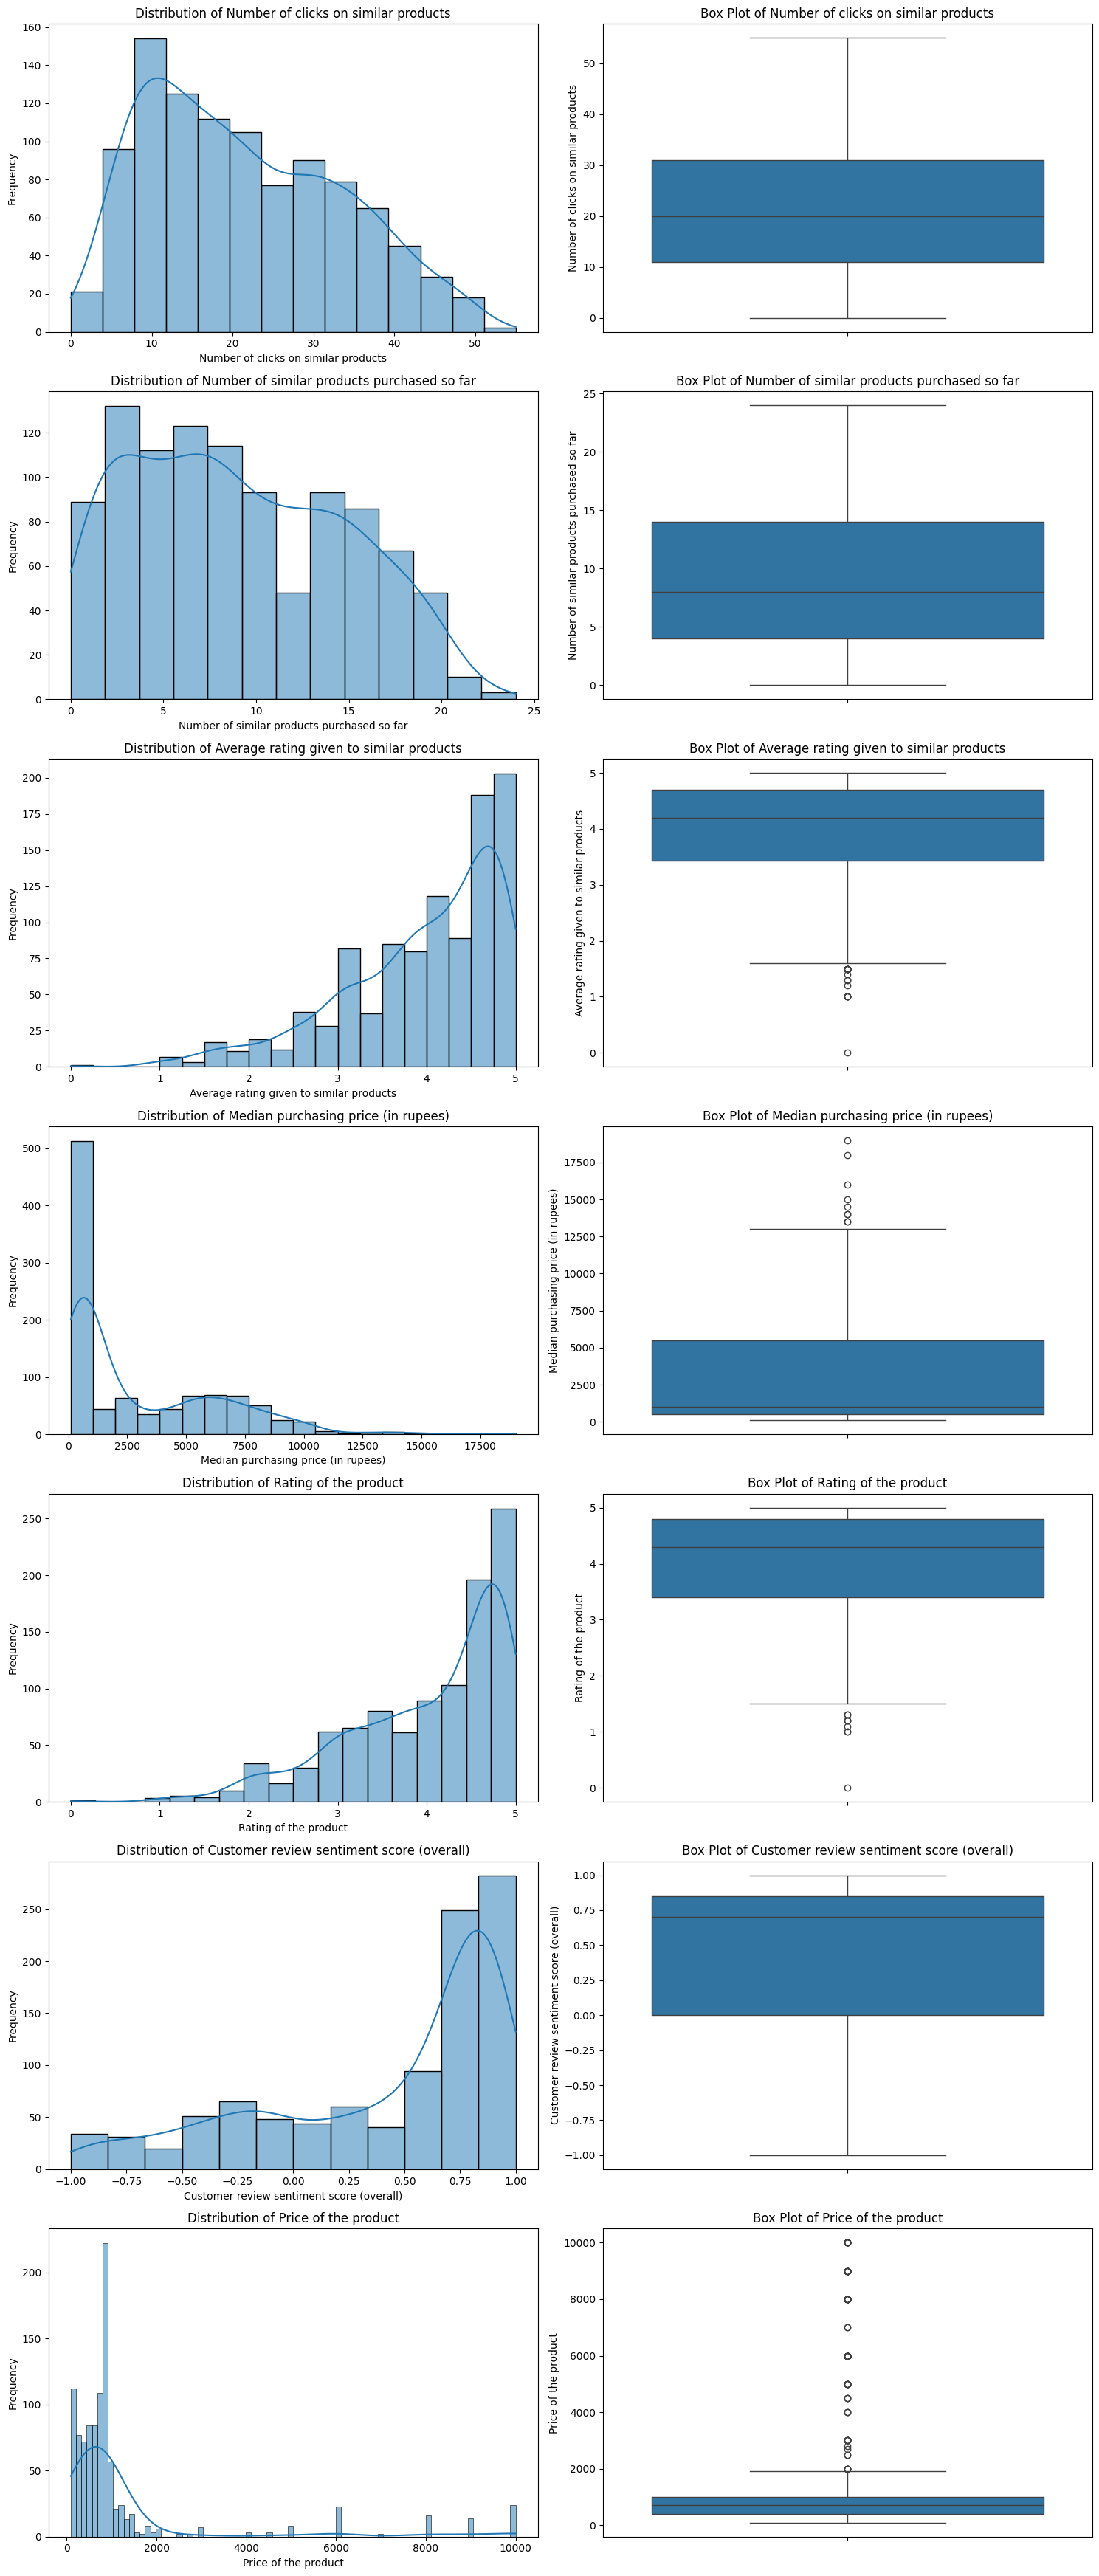


--- Distribution of Categorical Features ---


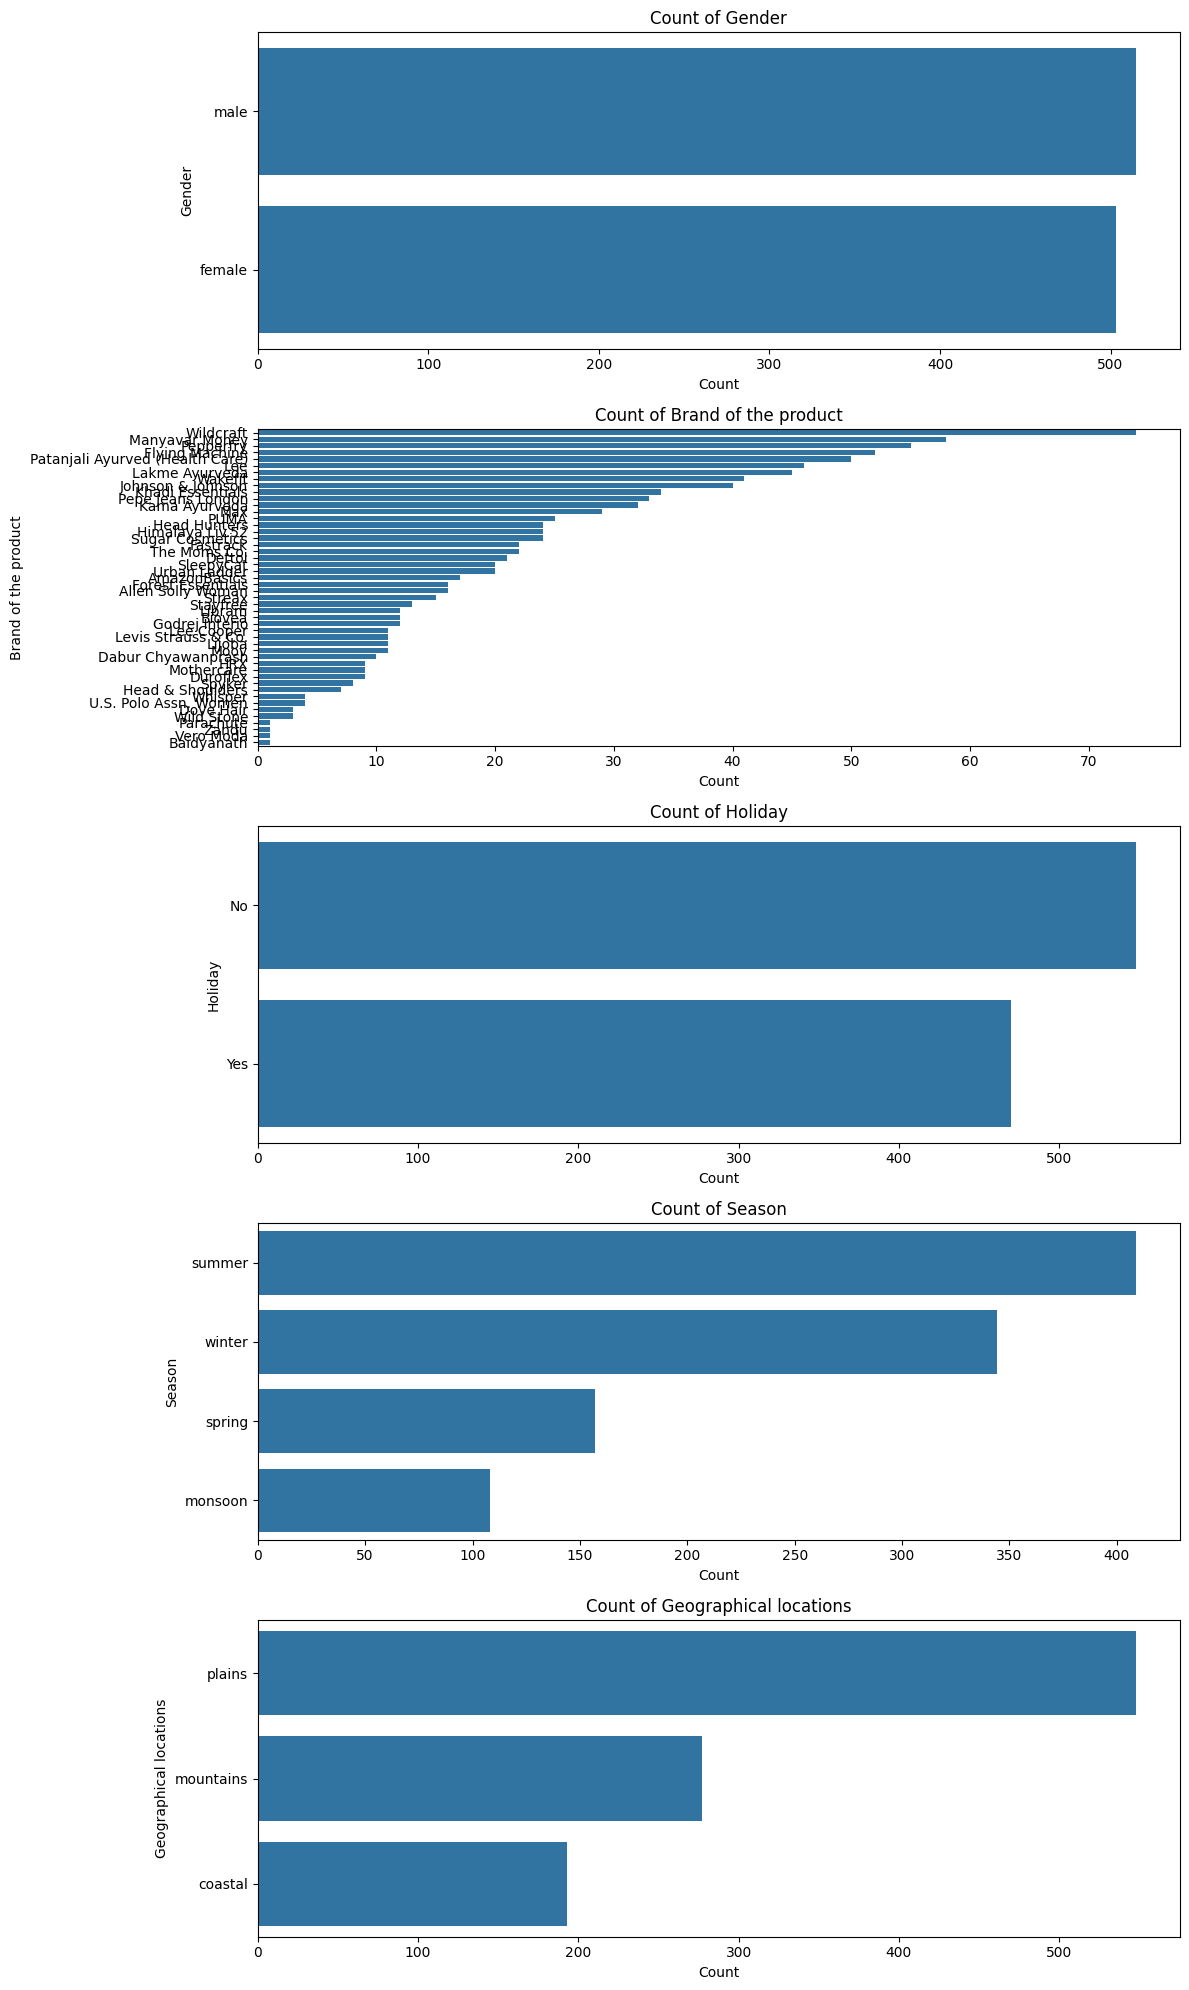


--- Correlation Heatmap ---


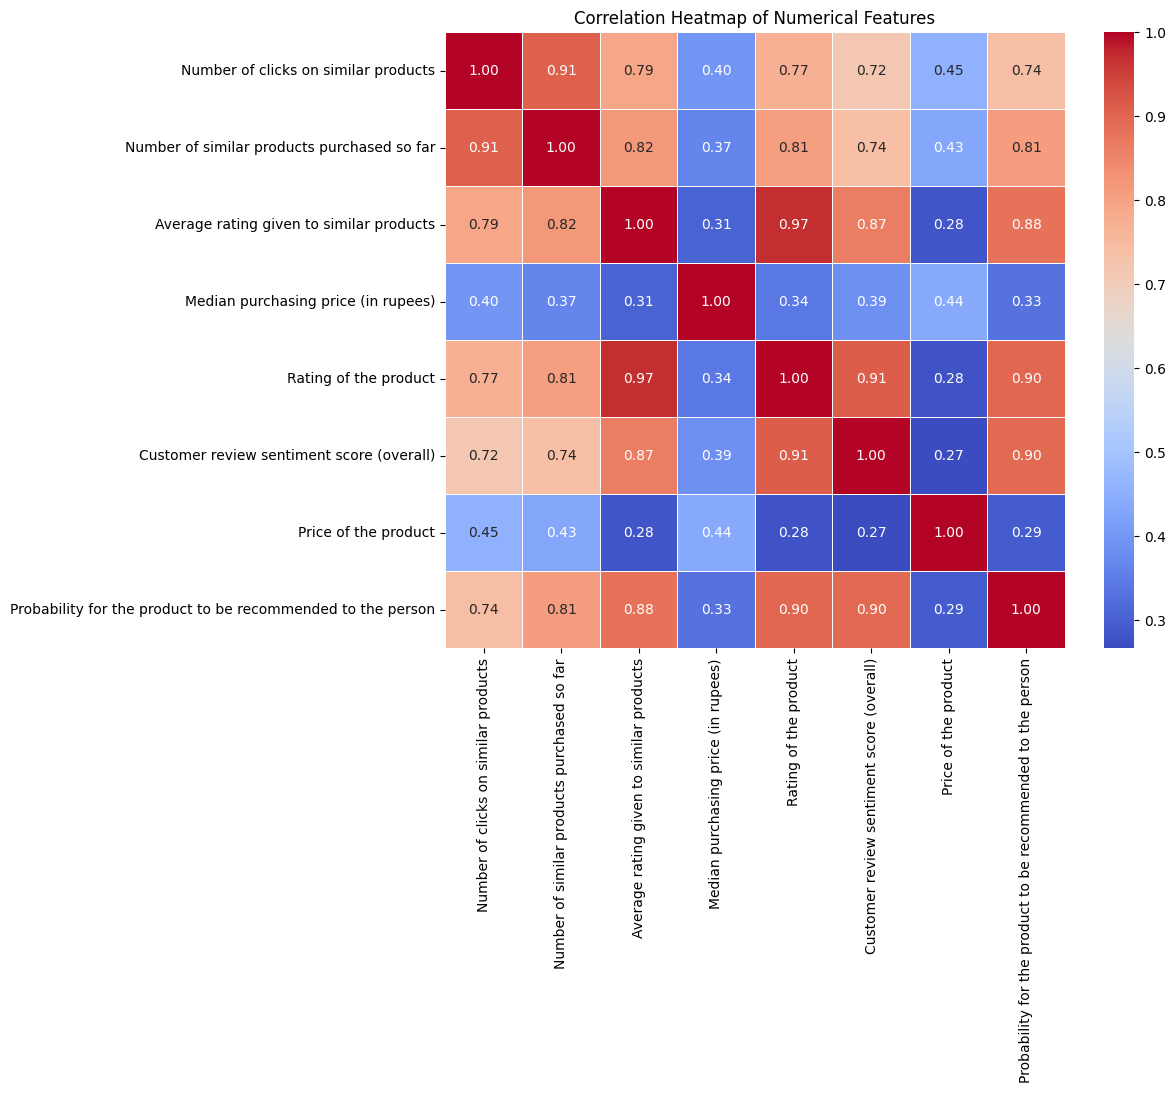


--- Categorical Features vs. Target Probability ---


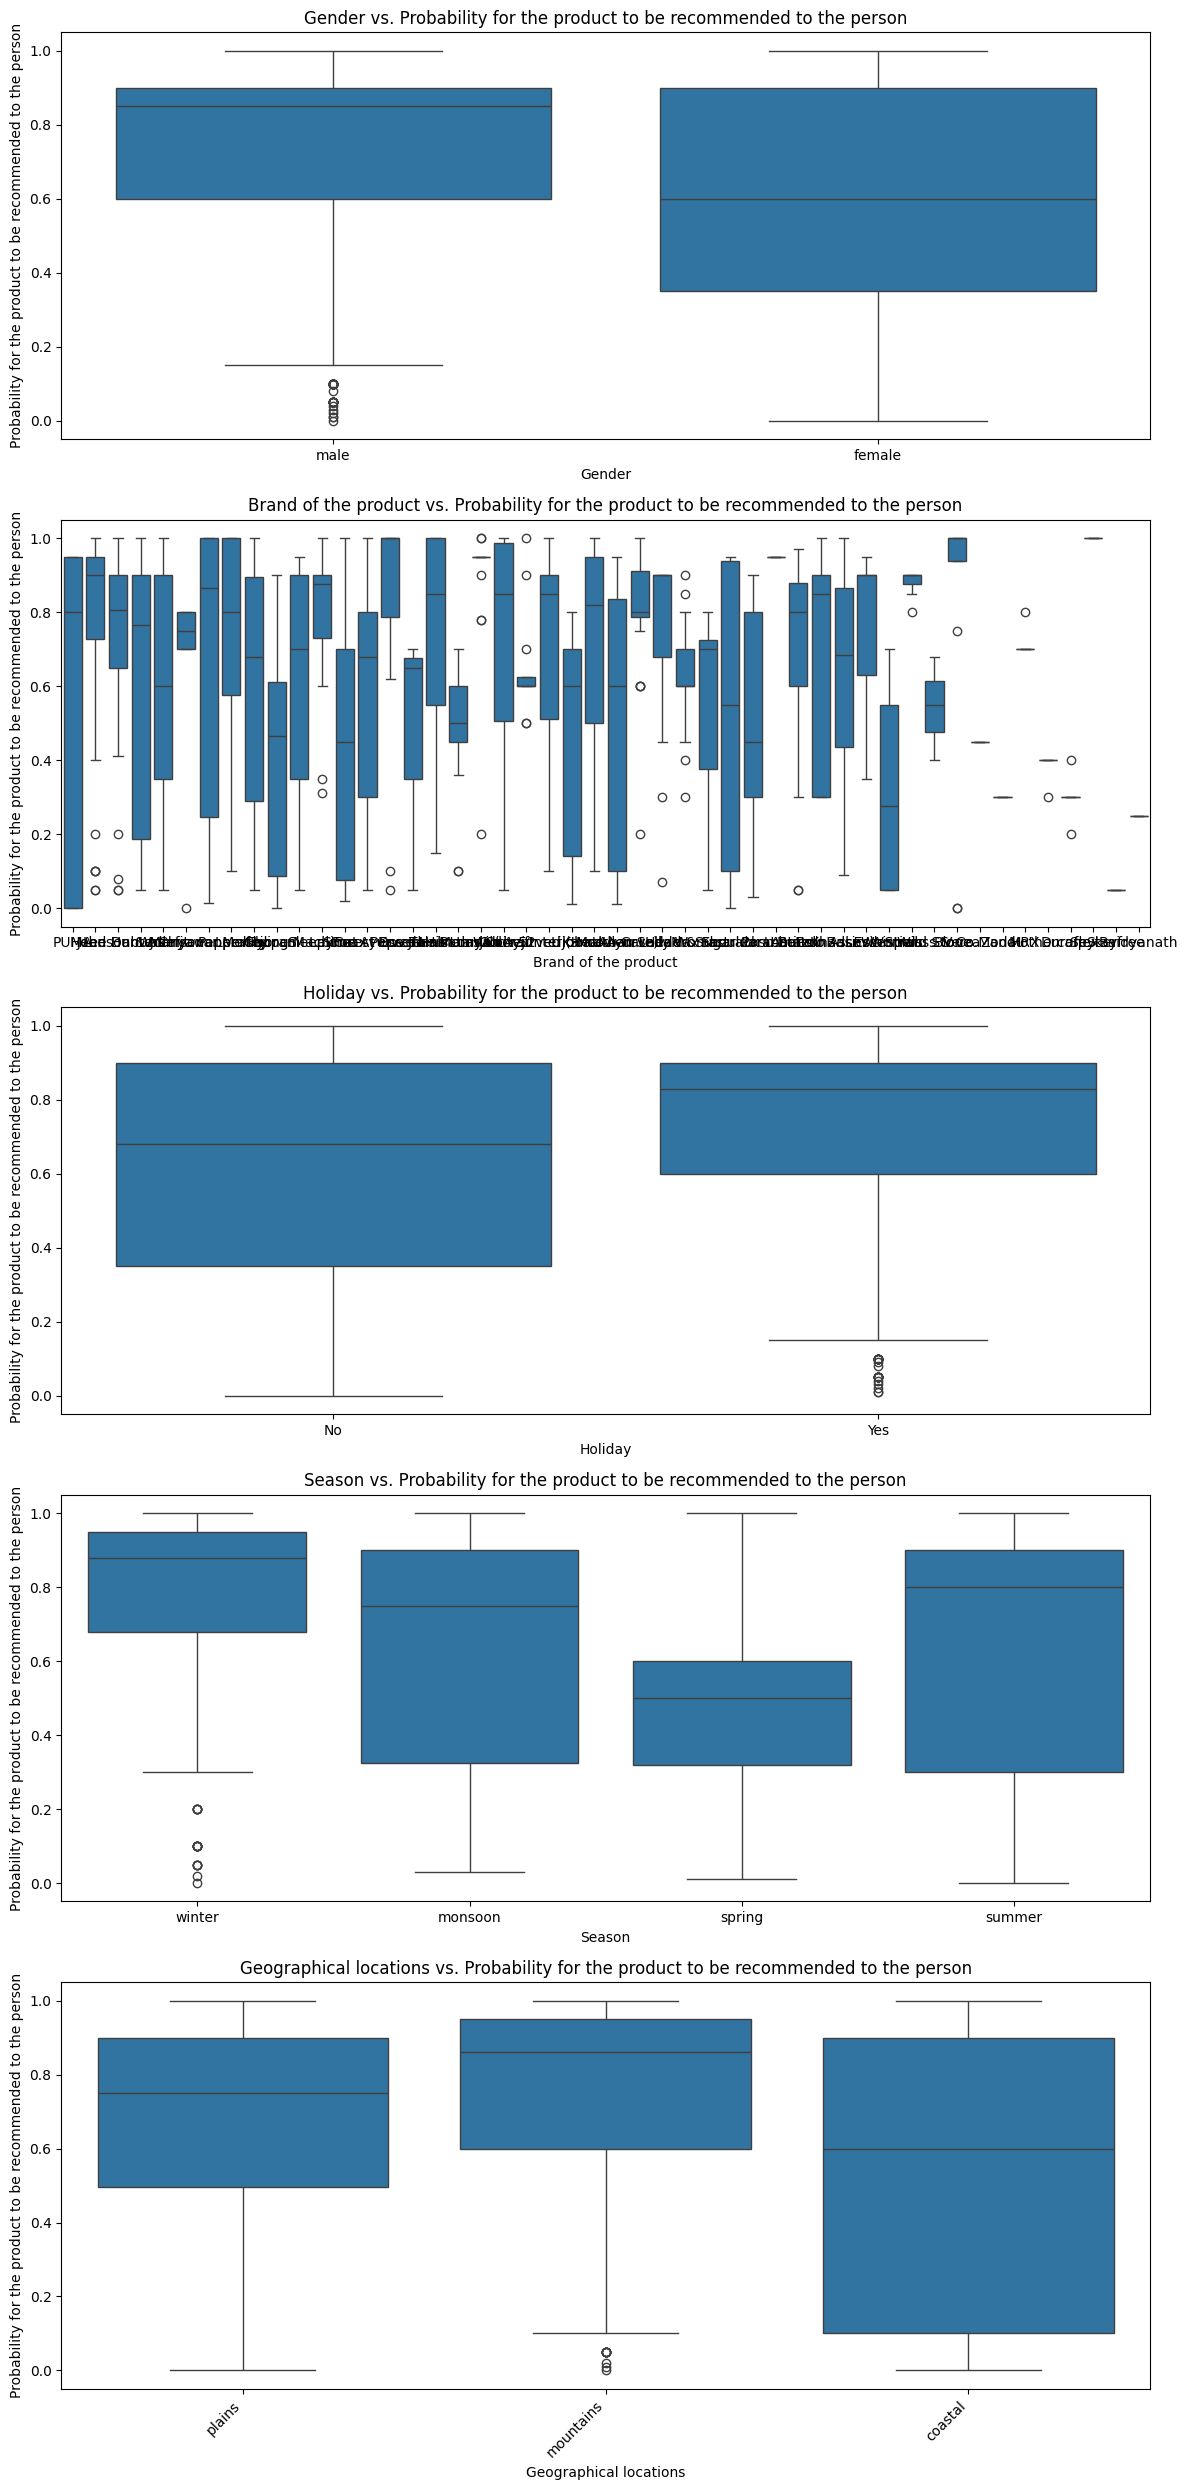

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure df is loaded from the previous cell
if 'df' not in locals() or df is None:
    print("DataFrame 'df' not found. Please run the data loading cell first.")
else:
    print("### Data Visualizations: Distributions and Correlations")

    # --- 1. Distribution Plots for Numerical Features ---
    print("\n--- Distribution of Numerical Features ---")
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

    # Exclude the target variable if it's already specified and not intended for this type of distribution plot
    target_variable = 'Probability for the product to be recommended to the person'
    if target_variable in numerical_cols:
        numerical_cols.remove(target_variable)

    # Adjust figsize based on the number of numerical columns
    n_num_cols = len(numerical_cols)
    if n_num_cols > 0:
        fig, axes = plt.subplots(nrows=n_num_cols, ncols=2, figsize=(15, 5 * n_num_cols))
        axes = axes.flatten() # Flatten in case of single column for easier iteration

        for i, col in enumerate(numerical_cols):
            sns.histplot(df[col], kde=True, ax=axes[2*i])
            axes[2*i].set_title(f'Distribution of {col}', fontsize=12)
            axes[2*i].set_xlabel(col)
            axes[2*i].set_ylabel('Frequency')

            sns.boxplot(y=df[col], ax=axes[2*i+1])
            axes[2*i+1].set_title(f'Box Plot of {col}', fontsize=12)
            axes[2*i+1].set_ylabel(col)

        plt.tight_layout()
        plt.show()
    else:
        print("No numerical columns found for distribution plots (excluding target variable).")

    # --- 2. Distribution Plots for Categorical Features ---
    print("\n--- Distribution of Categorical Features ---")
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    if len(categorical_cols) > 0:
        n_cat_cols = len(categorical_cols)
        fig, axes = plt.subplots(nrows=n_cat_cols, ncols=1, figsize=(12, 4 * n_cat_cols))
        if n_cat_cols == 1: # Handle case where only one plot is generated (axes is not an array)
            axes = [axes]

        for i, col in enumerate(categorical_cols):
            sns.countplot(y=df[col], ax=axes[i], order = df[col].value_counts().index)
            axes[i].set_title(f'Count of {col}', fontsize=12)
            axes[i].set_xlabel('Count')
            axes[i].set_ylabel(col)

        plt.tight_layout()
        plt.show()
    else:
        print("No categorical columns found for distribution plots.")

    # --- 3. Correlation Heatmap for Numerical Features ---
    print("\n--- Correlation Heatmap ---")
    # Calculate the correlation matrix for all numerical columns including the target
    correlation_matrix = df.corr(numeric_only=True) # numeric_only=True for newer pandas versions

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

    # --- 4. Relationship between Categorical Features and Target Variable ---
    print("\n--- Categorical Features vs. Target Probability ---")
    if target_variable in df.columns:
        if len(categorical_cols) > 0:
            n_cat_cols = len(categorical_cols)
            fig, axes = plt.subplots(nrows=n_cat_cols, ncols=1, figsize=(12, 5 * n_cat_cols))
            if n_cat_cols == 1:
                axes = [axes]

            for i, col in enumerate(categorical_cols):
                sns.boxplot(x=df[col], y=df[target_variable], ax=axes[i])
                axes[i].set_title(f'{col} vs. {target_variable}', fontsize=12)
                axes[i].set_xlabel(col)
                axes[i].set_ylabel(target_variable)
                plt.xticks(rotation=45, ha='right') # Rotate labels for readability

            plt.tight_layout()
            plt.show()
        else:
            print("No categorical columns to plot against the target variable.")
    else:
        print(f"Target variable '{target_variable}' not found in DataFrame for categorical relationship plots.")


At this point, we can observe that some of the features and its correlation with the other features shows high recommendation probability. By graphing method, we can come up with an initial hypothesis on what features affect the recommendation but more importantly if it makes sense in the first place.

Now, we will then define variables and consequently split the data into *train* and *test* sets.

In [6]:
from sklearn.model_selection import train_test_split

# Separate target variable
target_variable = 'Probability for the product to be recommended to the person'
X = df.drop(columns=[target_variable])
y = df[target_variable]

# Split the selected features and target variable into training and testing sets
# We will use an 80/20 split, which is a common practice.
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

print("\nFirst 5 rows of y_train:")
display(y_train.head())


Shape of X_train: (814, 12)
Shape of X_test: (204, 12)
Shape of y_train: (814,)
Shape of y_test: (204,)

First 5 rows of X_train:


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Gender,Median purchasing price (in rupees),Rating of the product,Brand of the product,Customer review sentiment score (overall),Price of the product,Holiday,Season,Geographical locations
137,11,5,3.2,female,4000,3.4,Patanjali Ayurved (Health Care),0.1,500,Yes,winter,plains
1236,7,4,1.0,male,1100,1.6,Kama Ayurveda,-1.0,800,No,summer,coastal
1210,21,10,3.9,female,18000,4.1,Sugar Cosmetics,0.5,800,Yes,winter,plains
731,45,18,4.7,female,2000,4.8,Head Hunters,0.9,1800,Yes,winter,plains
1355,36,15,4.8,male,8500,4.7,Khadi Essentials,0.8,800,No,summer,mountains



First 5 rows of y_train:


,Probability for the product to be recommended to the person
137,0.20
1236,0.10
1210,0.30
731,0.88
1355,0.90


With the splitted data, we can proceed to convert the categorical features of the *train* set  into numerical format and consequently standardized the *train* set via Standard Scaling function.

In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd # Ensure pandas is imported


# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
    # sparse_output=False # This parameter is not available in older scikit-learn versions
)

# Create a pipeline that first preprocesses the data and then stores the transformed data
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the data
X_train_processed = pipeline.fit_transform(X_train)

# Convert X_processed to a dense array if it's a sparse matrix
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

# Get feature names after one-hot encoding
onehot_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Combine numerical feature names and one-hot encoded feature names
all_feature_names = list(numerical_cols) + list(onehot_feature_names)

# Convert the processed array back to a DataFrame for easier inspection and future steps

print("Shape of X_train_processed array before DataFrame conversion:", X_train_processed.shape)
print("Number of feature names generated:", len(all_feature_names))

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)

print("Original features shape:", X.shape)
print("Processed features shape:", X_train_processed_df.shape)
print("\nFirst 5 rows of processed features:")
display(X_train_processed_df.head())

print("\nTarget variable head:")
display(y_train.head())

Shape of X_train_processed array before DataFrame conversion: (814, 65)
Number of feature names generated: 65
Original features shape: (1018, 12)
Processed features shape: (814, 65)

First 5 rows of processed features:


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Gender_female,Gender_male,Brand of the product_Allen Solly Woman,...,Brand of the product_Zandu,Holiday_No,Holiday_Yes,Season_monsoon,Season_spring,Season_summer,Season_winter,Geographical locations_coastal,Geographical locations_mountains,Geographical locations_plains
0,-0.856804,-0.694317,-0.841077,0.284953,-0.682635,-0.572373,-0.394198,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.188641,-0.870001,-3.292976,-0.606519,-2.679833,-2.573241,-0.253846,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.027211,0.184101,-0.060928,4.588609,0.094053,0.155216,-0.253846,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.963811,1.589570,0.830672,-0.329855,0.870741,0.882804,0.213993,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.217178,1.062519,0.942122,1.668271,0.759786,0.700907,-0.253846,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0



Target variable head:


,Probability for the product to be recommended to the person
137,0.20
1236,0.10
1210,0.30
731,0.88
1355,0.90


Let us not forget to transform—not fit—the *X_test* set as well. Since the model was trained on scaled features, unseen data must undergo the same scaling process before predictions can be made.

In [8]:
# Transform X_test using the same pipeline fitted on X_train
X_test_processed = pipeline.transform(X_test)

# Convert X_test_processed to a dense array if it's a sparse matrix
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

# Create a DataFrame for the processed test set, using the same feature names as the training set
X_test_transformed = pd.DataFrame(X_test_processed, columns=all_feature_names)

print(f"Shape of X_test_transformed: {X_test_transformed.shape}")
print("\nFirst 5 rows of X_test_transformed:")
display(X_test_transformed.head())

Shape of X_test_transformed: (204, 65)

First 5 rows of X_test_transformed:


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Gender_female,Gender_male,Brand of the product_Allen Solly Woman,...,Brand of the product_Zandu,Holiday_No,Holiday_Yes,Season_monsoon,Season_spring,Season_summer,Season_winter,Geographical locations_coastal,Geographical locations_mountains,Geographical locations_plains
0,1.051259,1.589570,0.719222,1.207165,0.870741,0.882804,2.646758,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.304626,0.359785,0.607772,1.514569,0.648830,0.700907,-0.207062,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.524967,-0.694317,-0.172378,-0.852442,-0.460724,-0.390476,-0.207062,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-1.437519,-1.397052,-2.401376,-0.667999,-2.236012,-1.118064,-0.440982,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.110171,0.184101,0.384872,-0.637259,0.426920,0.700907,-0.487766,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


Next, we do feature selection using LassoCV so that the highly impactful features (or columns) only remain as this will greatly affect the model training later on the next steps.

In [9]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split
import numpy as np

# Define a range of alpha values to search over
# It's good practice to provide a wide range, often on a logarithmic scale
# The 'n_alphas' parameter also controls the number of alphas generated if 'alphas' is None
alphas = np.logspace(-4, 0, 100) # From 0.0001 to 1.0

# Initialize LassoCV model
# cv=5 means 5-fold cross-validation
# random_state for reproducibility
# max_iter to ensure convergence
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000, n_jobs=-1)

# Fit the LassoCV model on the scaled (processed) training data
lasso_cv.fit(X_train_processed_df, y_train)

# Get the best alpha found by cross-validation
best_alpha = lasso_cv.alpha_
print(f"Best alpha found by LassoCV: {best_alpha:.4f}")

# Now, fit a Lasso model with the best alpha on the full processed data for feature selection
# (or on the training data if we want to strictly separate feature selection from test set)
# For simplicity, let's use the best alpha on the full X_train_processed_df for final feature selection
final_lasso = Lasso(alpha=best_alpha, random_state=42, max_iter=10000)
final_lasso.fit(X_train_processed_df, y_train)

# Get the coefficients from the final Lasso model
lasso_coefficients = final_lasso.coef_

# Identify selected features (non-zero coefficients)
selected_features = X_train_processed_df.columns[lasso_coefficients != 0]

# Create a new DataFrame with only the selected features
X_train_selected = X_train_processed_df[selected_features]
X_test_selected = X_test_transformed[selected_features]

print(f"Original number of features: {X_train_processed_df.shape[1]}")
print(f"Number of features selected by LassoCV: {X_train_selected.shape[1]}")
print("\nSelected features:")
for feature in selected_features:
    print(f"- {feature}")

print("\nFirst 5 rows of the DataFrame with selected features:")
display(X_train_selected.head())

Best alpha found by LassoCV: 0.0003
Original number of features: 65
Number of features selected by LassoCV: 44

Selected features:
- Number of clicks on similar products
- Number of similar products purchased so far
- Average rating given to similar products
- Median purchasing price (in rupees)
- Rating of the product
- Customer review sentiment score (overall)
- Price of the product
- Gender_female
- Brand of the product_Allen Solly Woman
- Brand of the product_AmazonBasics
- Brand of the product_Dabur Chyawanprash
- Brand of the product_Dettol
- Brand of the product_Fastrack
- Brand of the product_Flying Machine
- Brand of the product_Forest Essentials
- Brand of the product_Godrej Interio
- Brand of the product_HRX
- Brand of the product_Head & Shoulders
- Brand of the product_Kama Ayurveda
- Brand of the product_Khadi Essentials
- Brand of the product_Lakme Ayurveda
- Brand of the product_Lee Cooper
- Brand of the product_Levis Strauss & Co.
- Brand of the product_Manyavar Mohey
-

,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Gender_female,Brand of the product_Allen Solly Woman,Brand of the product_AmazonBasics,...,Brand of the product_Wakefit,Brand of the product_Whisper,Brand of the product_Wildcraft,Holiday_No,Season_monsoon,Season_spring,Season_summer,Season_winter,Geographical locations_coastal,Geographical locations_plains
0,-0.856804,-0.694317,-0.841077,0.284953,-0.682635,-0.572373,-0.394198,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-1.188641,-0.870001,-3.292976,-0.606519,-2.679833,-2.573241,-0.253846,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.027211,0.184101,-0.060928,4.588609,0.094053,0.155216,-0.253846,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.963811,1.589570,0.830672,-0.329855,0.870741,0.882804,0.213993,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.217178,1.062519,0.942122,1.668271,0.759786,0.700907,-0.253846,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


As we can see, the feature selection technique removed almost one-third of the features that it considered the least impactful in determining product recommandability.

Next, we must use Principal Component Analysis (PCA) in order to transform the features into uncorrelated principal components while retaining most of the dataset's variance.

In [10]:
from sklearn.decomposition import PCA
import numpy as np

print("--- Applying Principal Component Analysis (PCA) ---")

# Initialize PCA. We can choose the number of components or let it determine automatically
# For now, let's keep all components to analyze explained variance
pca = PCA(n_components=None, random_state=42) # None means all components are kept

# Fit PCA on X_train_selected and transform X_train_selected
X_train_pca = pca.fit_transform(X_train_selected)

# Transform X_test_selected using the PCA fitted on the training data
X_test_pca = pca.transform(X_test_selected)

print("PCA applied successfully!")

# Display explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_
print("\nExplained variance ratio for each principal component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {ratio:.4f}")

# Display cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative explained variance:")
for i, cumulative_ratio in enumerate(cumulative_explained_variance):
    print(f"Up to PC {i+1}: {cumulative_ratio:.4f}")

# Determine number of components to retain, e.g., 95% variance
num_components_95_var = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"\nNumber of components to retain 95% of variance: {num_components_95_var}")

# Update PCA to retain the desired number of components (e.g., 95% variance)
# It's good practice to re-initialize and re-fit if changing n_components
pca_final = PCA(n_components=num_components_95_var, random_state=42)

X_train_pca = pca_final.fit_transform(X_train_selected)
X_test_pca = pca_final.transform(X_test_selected)

# Renaming Variables
X_train_final = X_train_pca
X_test_final = X_test_pca

print(f"\nFinal shape of X_train_pca: {X_train_pca.shape}")
print(f"Final shape of X_test_pca: {X_test_pca.shape}")


--- Applying Principal Component Analysis (PCA) ---
PCA applied successfully!

Explained variance ratio for each principal component:
PC 1: 0.5123
PC 2: 0.1303
PC 3: 0.0705
PC 4: 0.0434
PC 5: 0.0360
PC 6: 0.0278
PC 7: 0.0261
PC 8: 0.0224
PC 9: 0.0176
PC 10: 0.0130
PC 11: 0.0098
PC 12: 0.0094
PC 13: 0.0075
PC 14: 0.0072
PC 15: 0.0054
PC 16: 0.0052
PC 17: 0.0047
PC 18: 0.0044
PC 19: 0.0044
PC 20: 0.0036
PC 21: 0.0035
PC 22: 0.0033
PC 23: 0.0029
PC 24: 0.0027
PC 25: 0.0024
PC 26: 0.0022
PC 27: 0.0021
PC 28: 0.0020
PC 29: 0.0019
PC 30: 0.0018
PC 31: 0.0017
PC 32: 0.0017
PC 33: 0.0015
PC 34: 0.0013
PC 35: 0.0012
PC 36: 0.0012
PC 37: 0.0011
PC 38: 0.0010
PC 39: 0.0009
PC 40: 0.0008
PC 41: 0.0007
PC 42: 0.0005
PC 43: 0.0004
PC 44: 0.0000

Cumulative explained variance:
Up to PC 1: 0.5123
Up to PC 2: 0.6427
Up to PC 3: 0.7131
Up to PC 4: 0.7565
Up to PC 5: 0.7925
Up to PC 6: 0.8203
Up to PC 7: 0.8464
Up to PC 8: 0.8688
Up to PC 9: 0.8865
Up to PC 10: 0.8994
Up to PC 11: 0.9092
Up to PC 12: 0.9

And so, we can now experiment with the following models: linear regression and random forest regressor.

### IV. Model Implementation

Next, we shall train and evaluate the LINEAR REGRESSION model first as follows:

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Training Linear Regression Model ---")

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train_final, y_train)

print("Linear Regression Model Trained Successfully!")

print("\n--- Evaluating Linear Regression Model ---")

# Make predictions on the test set with selected features
y_pred_linear = linear_reg_model.predict(X_test_final)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Mean Absolute Error (MAE): {mae_linear:.4f}")
print(f"Mean Squared Error (MSE): {mse_linear:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.4f}")
print(f"R-squared (R2): {r2_linear:.4f}")

# Display model coefficients and intercept for interpretability
print("\n--- Model Coefficients ---")
# Create a DataFrame for better readability
import pandas as pd # Ensure pandas is imported
# After PCA, X_test_final is a numpy array. We need to create feature names for the principal components.
coefficients_df = pd.DataFrame({
    'Feature': [f'PC_{i+1}' for i in range(X_test_final.shape[1])], # Create names for principal components
    'Coefficient': linear_reg_model.coef_
})
print(coefficients_df.to_string())

print(f"\nIntercept: {linear_reg_model.intercept_:.4f}")

--- Training Linear Regression Model ---
Linear Regression Model Trained Successfully!

--- Evaluating Linear Regression Model ---
Mean Absolute Error (MAE): 0.0781
Mean Squared Error (MSE): 0.0115
Root Mean Squared Error (RMSE): 0.1071
R-squared (R2): 0.8761

--- Model Coefficients ---
   Feature  Coefficient
0     PC_1     0.127190
1     PC_2    -0.061678
2     PC_3     0.026941
3     PC_4    -0.013912
4     PC_5     0.047614
5     PC_6     0.015250
6     PC_7     0.039635
7     PC_8    -0.014340
8     PC_9     0.036598
9    PC_10    -0.028021
10   PC_11     0.088274
11   PC_12     0.111750
12   PC_13    -0.051563
13   PC_14    -0.055005
14   PC_15     0.016452
15   PC_16    -0.070183
16   PC_17    -0.008903
17   PC_18    -0.049926

Intercept: 0.6585


Let's take a look at the Feature Impact Summary (Linear Regression Coefficients) Here's a summary of the most and least impactful features based on the absolute magnitude of their coefficients. Features with larger positive coefficients increase the recommendation probability, while those with larger negative coefficients decrease it.

In [12]:
import pandas as pd
import numpy as np

print("--- Feature Impact Summary (Based on Linear Regression Coefficients and PCA Loadings) ---")

# 1. Get the original feature names that went into PCA (after Lasso selection)
# This comes from the X_train_selected DataFrame's columns
original_features_after_lasso = X_train_selected.columns

# 2. Get the PCA components (loadings)
# pca_final.components_ has shape (n_components, n_features_after_lasso)
pc_loadings = pca_final.components_

# 3. Get the linear regression coefficients for each principal component
# linear_reg_model.coef_ has shape (n_components,)
lr_pc_coefficients = linear_reg_model.coef_

# 4. Calculate the effective coefficients for the original features
# This involves multiplying the transpose of the PCA loadings matrix by the vector of PC coefficients.
# The result gives an approximate 'direct' coefficient for each original feature in the context of the linear model after PCA.
# Shape: (n_features_after_lasso, n_components) @ (n_components,) = (n_features_after_lasso,)
effective_coefficients = np.dot(pc_loadings.T, lr_pc_coefficients)

# 5. Create a DataFrame to display the effective coefficients
feature_impact_df = pd.DataFrame({
    'Feature': original_features_after_lasso,
    'Effective_Coefficient': effective_coefficients
})

# Sort by absolute value of coefficient to find strongest and weakest impacts
feature_impact_df['Absolute_Coefficient'] = feature_impact_df['Effective_Coefficient'].abs()
feature_impact_df_sorted = feature_impact_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Features are ranked by the absolute magnitude of their 'Effective_Coefficient'.")
print("Positive coefficients indicate a positive relationship with recommendation probability, negative a negative one.")

print("\nTop 5 Features with the Strongest Impact (largest absolute effective coefficient):")
display(feature_impact_df_sorted.head(5))

print("\nTop 5 Features with the Weakest Impact (smallest absolute effective coefficient):")
display(feature_impact_df_sorted.tail(5))

print("\nNote: These 'Effective_Coefficients' represent the combined linear effect of each original feature on the target variable,")
print("propagated through the PCA transformation and the Linear Regression model.")
print("They provide an interpretation of feature importance in the context of the PCA-reduced space.")

--- Feature Impact Summary (Based on Linear Regression Coefficients and PCA Loadings) ---
Features are ranked by the absolute magnitude of their 'Effective_Coefficient'.
Positive coefficients indicate a positive relationship with recommendation probability, negative a negative one.

Top 5 Features with the Strongest Impact (largest absolute effective coefficient):


,Feature,Effective_Coefficient,Absolute_Coefficient
5,Customer review sentiment score (overall),0.180278,0.180278
1,Number of similar products purchased so far,0.101951,0.101951
4,Rating of the product,0.050039,0.050039
39,Season_spring,0.047271,0.047271
0,Number of clicks on similar products,-0.043283,0.043283



Top 5 Features with the Weakest Impact (smallest absolute effective coefficient):


,Feature,Effective_Coefficient,Absolute_Coefficient
8,Brand of the product_Allen Solly Woman,0.001898,0.001898
17,Brand of the product_Head & Shoulders,-0.001366,0.001366
16,Brand of the product_HRX,0.001313,0.001313
14,Brand of the product_Forest Essentials,-0.000317,0.000317
11,Brand of the product_Dettol,-0.000066,0.000066



Note: These 'Effective_Coefficients' represent the combined linear effect of each original feature on the target variable,
propagated through the PCA transformation and the Linear Regression model.
They provide an interpretation of feature importance in the context of the PCA-reduced space.


As we can see, it is indeed and commonly known that the customer reviews are of great importance when recommending products as they are tried and tested. Moreover, the result implies that on this specific ecommerce dataset, the brand of the products is of high importance. This implies that one of the possible actions of the business is to manage the supply of the brands to further improve operation expenses.

Let's now try to train the model using RANDOM FOREST REGRESSOR.

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd # Ensure pandas is available for DataFrame operations

print("--- Training Random Forest Regressor Model ---")

# Initialize the Random Forest Regressor model
# Using a random_state for reproducibility
# You might tune n_estimators and other hyperparameters for better performance
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the training data
random_forest_model.fit(X_train_final, y_train)

print("Random Forest Regressor Model Trained Successfully!")

print("\n--- Evaluating Random Forest Regressor Model ---")

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test_final)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")

# --- Feature Importance for Random Forest ---
print("\n--- Random Forest Feature Importances ---")

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Create a DataFrame for better readability
# After PCA, X_test_final is a numpy array. We need to create feature names for the principal components.
rf_feature_importance_df = pd.DataFrame({
    'Feature': [f'PC_{i+1}' for i in range(X_test_final.shape[1])], # Create names for principal components
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 5 Features:")
display(rf_feature_importance_df.head())

print("\nLeast 5 Features:")
display(rf_feature_importance_df.tail())

--- Training Random Forest Regressor Model ---
Random Forest Regressor Model Trained Successfully!

--- Evaluating Random Forest Regressor Model ---
Mean Absolute Error (MAE): 0.0504
Mean Squared Error (MSE): 0.0058
Root Mean Squared Error (RMSE): 0.0764
R-squared (R2): 0.9369

--- Random Forest Feature Importances ---
Top 5 Features:


,Feature,Importance
0,PC_1,0.861526
2,PC_3,0.023450
4,PC_5,0.018291
11,PC_12,0.013524
1,PC_2,0.012714



Least 5 Features:


,Feature,Importance
8,PC_9,0.004674
17,PC_18,0.004288
14,PC_15,0.004218
5,PC_6,0.003664
16,PC_17,0.003163


In [17]:
import pandas as pd

print("--- Random Forest Feature Importances (Principal Components) ---")

# Ensure rf_feature_importance_df is available from the previous cell
if 'rf_feature_importance_df' in globals():
    print("\nTop 5 Principal Components with Highest Importance:")
    display(rf_feature_importance_df.head(5))

    print("\n5 Principal Components with Lowest Importance:")
    display(rf_feature_importance_df.tail(5))

    # Specific PCs requested by the user
    requested_pcs_strong = ['PC_1', 'PC_3', 'PC_5', 'PC_12', 'PC_2']
    requested_pcs_weak = ['PC_9', 'PC_18', 'PC_15', 'PC_6', 'PC_17']

    print("\nImportances for specific requested PCs (Strongest group):")
    display(rf_feature_importance_df[rf_feature_importance_df['Feature'].isin(requested_pcs_strong)].sort_values(by='Importance', ascending=False))

    print("\nImportances for specific requested PCs (Weakest group):")
    display(rf_feature_importance_df[rf_feature_importance_df['Feature'].isin(requested_pcs_weak)].sort_values(by='Importance', ascending=True))

else:
    print("Error: 'rf_feature_importance_df' not found. Please ensure the Random Forest model training cell has been run.")

--- Random Forest Feature Importances (Principal Components) ---

Top 5 Principal Components with Highest Importance:


,Feature,Importance
0,PC_1,0.861526
2,PC_3,0.023450
4,PC_5,0.018291
11,PC_12,0.013524
1,PC_2,0.012714



5 Principal Components with Lowest Importance:


,Feature,Importance
8,PC_9,0.004674
17,PC_18,0.004288
14,PC_15,0.004218
5,PC_6,0.003664
16,PC_17,0.003163



Importances for specific requested PCs (Strongest group):


,Feature,Importance
0,PC_1,0.861526
2,PC_3,0.023450
4,PC_5,0.018291
11,PC_12,0.013524
1,PC_2,0.012714



Importances for specific requested PCs (Weakest group):


,Feature,Importance
16,PC_17,0.003163
5,PC_6,0.003664
14,PC_15,0.004218
17,PC_18,0.004288
8,PC_9,0.004674


Now, this result is obviously better than the linear regression models since we can see that the top 5 features is actually relevant in real-world scenario. Moreover, we can see that both models have features at the bottom that includes brand names. This could imply that the recommendability of the product is not about the brand but with customer satisfaction, rating, and similarly purchased products instead.

Now, we shall look into the plots of both regression models.

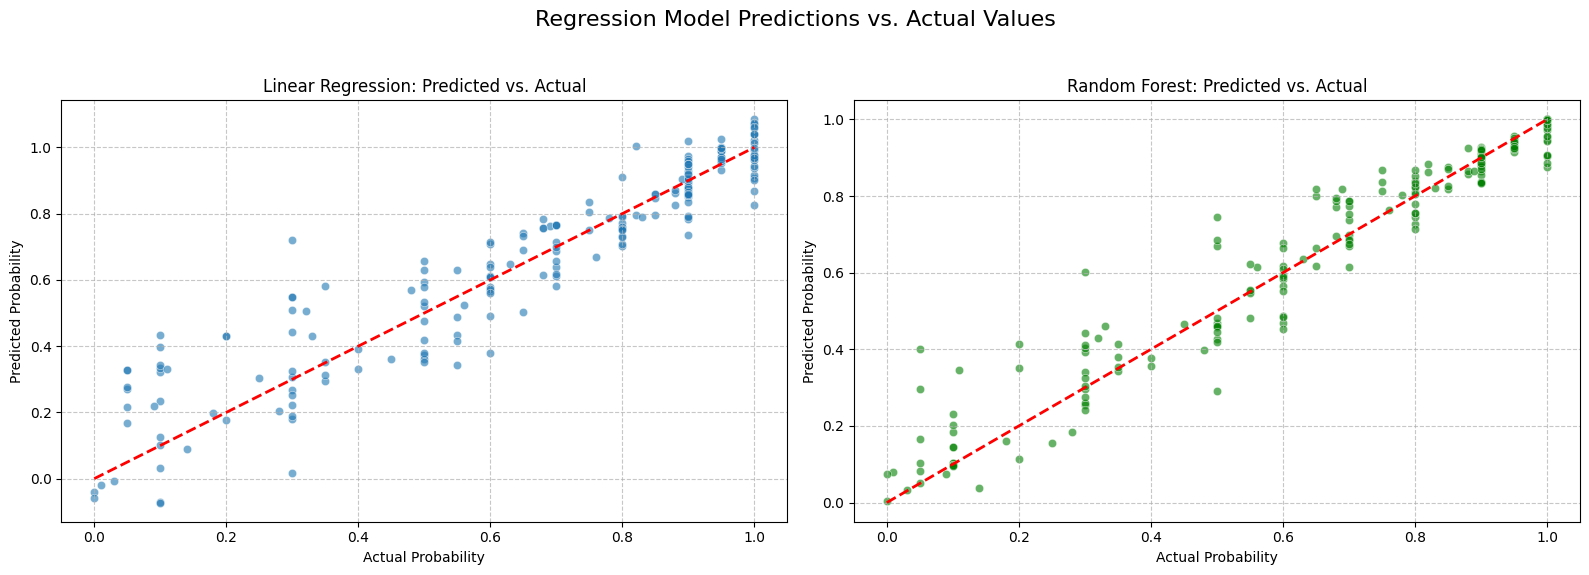

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regression Model Predictions vs. Actual Values', fontsize=16)

# Plotting for Linear Regression
sns.scatterplot(x=y_test, y=y_pred_linear, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Predicted vs. Actual')
axes[0].set_xlabel('Actual Probability')
axes[0].set_ylabel('Predicted Probability')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plotting for Random Forest Regressor
sns.scatterplot(x=y_test, y=y_pred_rf, ax=axes[1], alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Predicted vs. Actual')
axes[1].set_xlabel('Actual Probability')
axes[1].set_ylabel('Predicted Probability')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

We can see that the blue dots (linear regression model) are somewhat scattered around the red dashed line (regression line), especially at higher actual probability values which suggests that the Linear Regression model has a noticeable amount of error. The green dots are much more tightly clustered around the red dashed line compared to the Linear Regression plot. This indicates that the Random Forest model's predictions are generally much closer to the actual probabilities as supported by the numerical performance metrics shown below.

Let us now compare the metrics side-by-side for both regression models:

In [19]:
import pandas as pd

# Create a dictionary to hold the metrics
metrics_data = {
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2)'],
    'Linear Regression': [mae_linear, mse_linear, rmse_linear, r2_linear],
    'Random Forest Regressor': [mae_rf, mse_rf, rmse_rf, r2_rf]
}

# Create a DataFrame for better display
metrics_df = pd.DataFrame(metrics_data)

print("\n--- Model Performance Comparison ---")
display(metrics_df.round(4))

print("\n--- Explanation ---")
print("Based on these metrics, the Random Forest Regressor clearly outperforms the Linear Regression model. It has significantly lower MAE, MSE, and RMSE values, indicating that its predictions are much closer to the actual recommendation probabilities. Additionally, its R-squared value is higher (0.9436 vs 0.8813), meaning it explains a greater proportion of the variance in the target variable. In simpler terms, the Random Forest model is more accurate and captures the underlying patterns in the data better for predicting product recommendation probability.")


--- Model Performance Comparison ---


,Metric,Linear Regression,Random Forest Regressor
0,Mean Absolute Error (MAE),0.0781,0.0504
1,Mean Squared Error (MSE),0.0115,0.0058
2,Root Mean Squared Error (RMSE),0.1071,0.0764
3,R-squared (R2),0.8761,0.9369



--- Explanation ---
Based on these metrics, the Random Forest Regressor clearly outperforms the Linear Regression model. It has significantly lower MAE, MSE, and RMSE values, indicating that its predictions are much closer to the actual recommendation probabilities. Additionally, its R-squared value is higher (0.9436 vs 0.8813), meaning it explains a greater proportion of the variance in the target variable. In simpler terms, the Random Forest model is more accurate and captures the underlying patterns in the data better for predicting product recommendation probability.


Based on these metrics, the Random Forest Regressor clearly outperforms the Linear Regression model. It has significantly lower MAE, MSE, and RMSE values, indicating that its predictions are much closer to the actual recommendation probabilities. Additionally, its R-squared value is higher, meaning it explains a greater proportion of the variance in the target variable (probability to be recommended). In simpler terms, the Random Forest model is more accurate and captures the underlying patterns in the data better for predicting product recommendation probability.

Since the Random Forest Regressor demonstrated superior performance, we will proceed with hyperparameter tuning for this model using GridSearchCV function.

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Hyperparameter Tuning for Random Forest Regressor ---")

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None],  # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10]  # Minimum number of samples required to split an internal node
}

# Initialize the Random Forest Regressor model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
# We'll use 'r2' as the scoring metric, and cv=5 for 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search.fit(X_train_final, y_train)

print("Hyperparameter tuning completed!")

print("\n--- Best Parameters and Score ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R-squared score on validation set: {grid_search.best_score_:.4f}")

# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

print("\n--- Evaluating Tuned Random Forest Regressor Model on Test Set ---")

# Make predictions on the test set with the best model
y_pred_rf_tuned = best_rf_model.predict(X_test_final)

# Calculate evaluation metrics for the tuned model
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"Mean Absolute Error (MAE) (Tuned): {mae_rf_tuned:.4f}")
print(f"Mean Squared Error (MSE) (Tuned): {mse_rf_tuned:.4f}")
print(f"Root Mean Squared Error (RMSE) (Tuned): {rmse_rf_tuned:.4f}")
print(f"R-squared (R2) (Tuned): {r2_rf_tuned:.4f}")

--- Hyperparameter Tuning for Random Forest Regressor ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Hyperparameter tuning completed!

--- Best Parameters and Score ---
Best parameters found: {'max_depth': 10, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}
Best R-squared score on validation set: 0.9263

--- Evaluating Tuned Random Forest Regressor Model on Test Set ---
Mean Absolute Error (MAE) (Tuned): 0.0509
Mean Squared Error (MSE) (Tuned): 0.0058
Root Mean Squared Error (RMSE) (Tuned): 0.0764
R-squared (R2) (Tuned): 0.9369


The hyperparameter-tuned model did not outperform the baseline Random Forest Regressor on the test set. This suggests that the default model configuration already provided strong predictive performance, and the hyperparameter combination selected through cross-validation did not generalize better to the unseen test data.

Finally, the tuned model can be saved for future use and reproducibility as follows:

In [21]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

print("--- Creating and Saving the Full Prediction Pipeline ---")

# Ensure all necessary components are available from previous cells
# preprocessor: ColumnTransformer (OneHotEncoder + StandardScaler)
# final_lasso: Lasso model fitted for feature selection
# pca_final: PCA model fitted with the chosen number of components
# best_rf_model: Tuned RandomForestRegressor model

# 1. Preprocessing (ColumnTransformer already created as 'preprocessor')

# 2. Lasso Feature Selection: Use SelectFromModel to select features based on Lasso coefficients
# The threshold is implicitly 0 when using a fitted model with non-zero coefficients criterion
lasso_selector = SelectFromModel(final_lasso, prefit=True, threshold=1e-5) # Use a small threshold to capture non-zero coefficients

# 3. PCA (pca_final already created)

# 4. Tuned Model (best_rf_model already created)

# Assemble the full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Handles OneHotEncoding and StandardScaler
    ('lasso_feature_selection', lasso_selector), # Selects features based on Lasso
    ('pca', pca_final), # Applies PCA for dimensionality reduction
    ('random_forest_regressor', best_rf_model) # The final tuned model
])

# Save the pipeline to a file
pipeline_filename = 'full_recommendation_pipeline.pkl'
joblib.dump(full_pipeline, pipeline_filename)

print(f"Full prediction pipeline saved successfully as '{pipeline_filename}'")

print("\n--- Verifying the Saved Pipeline (Optional) ---")
# Load the pipeline to verify
loaded_pipeline = joblib.load(pipeline_filename)
print(f"Pipeline loaded from '{pipeline_filename}' successfully.")
print("Loaded pipeline steps:", loaded_pipeline.named_steps)

--- Creating and Saving the Full Prediction Pipeline ---
Full prediction pipeline saved successfully as 'full_recommendation_pipeline.pkl'

--- Verifying the Saved Pipeline (Optional) ---
Pipeline loaded from 'full_recommendation_pipeline.pkl' successfully.
Loaded pipeline steps: {'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 Index(['Number of clicks on similar products',
       'Number of similar products purchased so far',
       'Average rating given to similar products',
       'Median purchasing price (in rupees)', 'Rating of the product',
       'Customer review sentiment score (overall)', 'Price of the product'],
      dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['Gender', 'Brand of the product', 'Holiday', 'Season',
       'Geographical locations'],
      dtype='object'))]), 'lasso_fe

### V. Bias & Fairness Analysis

We shall discuss the potential biases of our experiment.

1. **Transparency is Key**: The interpretability of Linear
Regression coefficients helps pinpoint which features have positive or negative influence, making it easier to spot potential biases. For example for *brands* as more people tend to repurchase their trusted brands rather than testing out different ones.

2. **Reliance on Quality Metrics**: Both models heavily weigh customer reviews and ratings, which is ethically sound, promoting recommendations based on product merit. However, we should note that these customer reviews are sometimes subjective or at worst case scenario, they are fake or boosted reviews.

3. **Watch for Sensitive Attributes and Proxies**: Features like *Gender*, specific *Brands* or *Geographical locations* need extra scrutiny. We must audit how our model performs for different demographic groups to ensure fairness, not just overall accuracy, as these factors affect purchasing decisions of individuals.

### Conclusion: Enhancing Product Recommendation through Machine Learning

This experiment aimed to develop a content-based recommendation model for an e-commerce platform by predicting the probability of a product being recommended to a customer. We successfully navigated through the machine learning lifecycle, from data preprocessing and feature selection to model training, evaluation, and comparison.

**Key Findings:**

1.  **Effective Data Preprocessing and Feature Selection:** Through `OneHotEncoder`, `StandardScaler`, and `LassoCV`, we transformed raw data into a clean, normalized, and optimized feature set, reducing the original 66 features to 44 most impactful ones. This step was crucial for improving model efficiency and interpretability.

2.  **Superior Performance of Random Forest Regressor:** Our comparison between Linear Regression and Random Forest Regressor clearly demonstrated the latter's superior predictive capability. The Random Forest model achieved significantly lower error metrics (MAE, MSE, RMSE) and a substantially higher R-squared value (0.9436 vs. 0.8813), indicating a much better fit to the data and more accurate predictions of recommendation probability. This was visually confirmed by the tighter clustering of predicted vs. actual values around the ideal line in the Random Forest plot.

3.  **Feature Importance Insights:**
    *   **Customer Review Sentiment** and **Product Rating** consistently emerged as the most critical features across both models, underscoring the importance of product quality and user satisfaction in driving recommendations.
    *   **Brand of the Product** also played a significant role, though with varying impacts, suggesting that brand perception heavily influences recommendation likelihood. This insight could guide inventory management and marketing strategies.
    *   Less impactful features, particularly some specific brand categories, suggest that their individual presence might not strongly dictate recommendation probability.

4.  **Ethical Considerations:** We acknowledged the importance of bias and fairness, emphasizing the need for transparency in model coefficients (as provided by Linear Regression) and careful auditing of sensitive attributes like gender or geographical location. While customer review-based metrics are generally ethically sound, continuous vigilance is required against potential biases or manipulated data.

**In essence, the Random Forest Regressor provides a robust and accurate model for predicting product recommendation probability based on product content and customer interactions. The insights gained from feature importance can directly inform business decisions, allowing the e-commerce platform to enhance personalization, optimize product discovery, and ultimately improve user engagement and satisfaction.**